In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df=pd.read_excel("IAU.xlsx")

In [71]:
df

,Üniversite Adı,Bölüm,Puan Türü,Kontenjan,Taban Puan,Sıralama,Fiyat
0,İstanbul Aydın Üniversitesi (Vakıf),Adalet (%50 İnd. İ.Ö.),TYT,43,214.2947,1240256.0,13000.0
1,İstanbul Aydın Üniversitesi (Vakıf),Adalet (%50 İnd.),TYT,29,253.0896,757389.0,13000.0
2,İstanbul Aydın Üniversitesi (Vakıf),Adalet (Burslu İ.Ö.),TYT,7,286.2917,447396.0,NaN
3,İstanbul Aydın Üniversitesi (Vakıf),Adalet (Burslu),TYT,7,290.7827,416398.0,NaN
4,İstanbul Aydın Üniversitesi (Vakıf),Adalet (Ücretli),TYT,13,Dolmadı,NaN,26000.0
...,...,...,...,...,...,...,...
343,İstanbul Aydın Üniversitesi (Vakıf),Yazılım Mühendisliği (Burslu İng.),SAY,11,405.1399,39325.0,NaN
344,İstanbul Aydın Üniversitesi (Vakıf),Yeni Medya ve İletişim(%50 İnd.),SÖZ,38,250.5487,345591.0,23000.0
345,İstanbul Aydın Üniversitesi (Vakıf),Yeni Medya ve İletişim(Burslu),SÖZ,6,337.2907,38806.0,NaN
346,İstanbul Aydın Üniversitesi (Vakıf),Yönetim Bilişim Sistemleri (Burslu),EA,11,317.652,105845.0,NaN


In [72]:
len(df.index)

348

In [73]:
print(df.isnull().sum())

Üniversite Adı      0
Bölüm               0
Puan Türü           0
Kontenjan           0
Taban Puan          0
Sıralama           97
Fiyat             170
dtype: int64


In [75]:
df2=(df.Fiyat.interpolate(method="linear")) #Lineer regresyon ile Fiyat kolonundaki eksik verileri tahmin etti


In [76]:
df2

0      13000.000000
1      13000.000000
2      17333.333333
3      21666.666667
4      26000.000000
           ...     
343    23500.000000
344    23000.000000
345    22333.333333
346    21666.666667
347    21000.000000
Name: Fiyat, Length: 348, dtype: float64

In [78]:
df.groupby("Puan Türü").mean() #Puan türüne göre ortalamaları aldım

,Kontenjan,Sıralama,Fiyat
Puan Türü,,,
DİL,24.416667,21381.777778,22583.333333
EA,32.794118,208075.428571,24558.823529
SAY,28.583333,156531.166667,35864.583333
SÖZ,24.862069,115865.809524,24350.000000
TYT,26.462222,801334.170732,12161.422414


In [96]:
df[df["Sıralama"]==df["Sıralama"].min()] #Tıp vs bölümlerin Taban puanları belli olmadıgından onları almıyor(Dolmadı)

,Üniversite Adı,Bölüm,Puan Türü,Kontenjan,Taban Puan,Sıralama,Fiyat
230,İstanbul Aydın Üniversitesi (Vakıf),Özel Eğitim Öğretmenliği,SÖZ,9,385.6464,6304.0,NaN


In [98]:
df["Bölüm"].nunique() #347 Farklı Bölüm Var

347

In [101]:
df["Puan Türü"].value_counts() #Türlere Göre Bölüm Sayısı

TYT    225
SAY     48
EA      34
SÖZ     29
DİL     12
Name: Puan Türü, dtype: int64

In [106]:
df[df["Sıralama"]==df["Sıralama"].max()]["Sıralama"] 

194    1605582.0
251    1605582.0
Name: Sıralama, dtype: float64

In [125]:
df2=df.fillna(0)

In [126]:
df2

,Üniversite Adı,Bölüm,Puan Türü,Kontenjan,Taban Puan,Sıralama,Fiyat
0,İstanbul Aydın Üniversitesi (Vakıf),Adalet (%50 İnd. İ.Ö.),TYT,43,214.2947,1240256.0,13000.0
1,İstanbul Aydın Üniversitesi (Vakıf),Adalet (%50 İnd.),TYT,29,253.0896,757389.0,13000.0
2,İstanbul Aydın Üniversitesi (Vakıf),Adalet (Burslu İ.Ö.),TYT,7,286.2917,447396.0,0.0
3,İstanbul Aydın Üniversitesi (Vakıf),Adalet (Burslu),TYT,7,290.7827,416398.0,0.0
4,İstanbul Aydın Üniversitesi (Vakıf),Adalet (Ücretli),TYT,13,Dolmadı,0.0,26000.0
...,...,...,...,...,...,...,...
343,İstanbul Aydın Üniversitesi (Vakıf),Yazılım Mühendisliği (Burslu İng.),SAY,11,405.1399,39325.0,0.0
344,İstanbul Aydın Üniversitesi (Vakıf),Yeni Medya ve İletişim(%50 İnd.),SÖZ,38,250.5487,345591.0,23000.0
345,İstanbul Aydın Üniversitesi (Vakıf),Yeni Medya ve İletişim(Burslu),SÖZ,6,337.2907,38806.0,0.0
346,İstanbul Aydın Üniversitesi (Vakıf),Yönetim Bilişim Sistemleri (Burslu),EA,11,317.652,105845.0,0.0


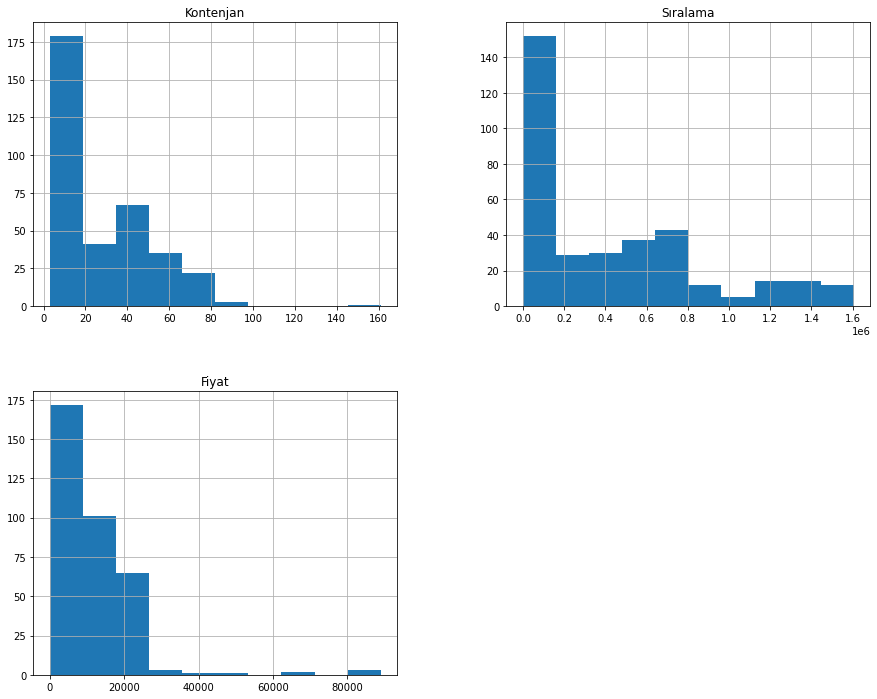

In [137]:
from pylab import rcParams
rcParams['figure.figsize'] = 15,12
df2.hist();

In [138]:
df2["Sıralama"].mean()

413934.275862069

In [139]:
df2["Fiyat"].mean()

9165.87643678161

In [140]:
df.groupby("Kontenjan").mean()

,Sıralama,Fiyat
Kontenjan,,
3,3.808654e+05,18375.000000
4,4.549318e+05,NaN
5,4.262099e+05,NaN
6,4.305646e+05,NaN
7,5.413448e+05,18375.000000
...,...,...
74,1.375366e+06,10500.000000
76,9.878238e+05,10500.000000
78,5.224900e+05,10500.000000


In [146]:
def ya_find(bul):
    if "ya" in bul.lower():   #Bölümlerin içerisinde 'ya' gecen kelimeleri alır
        return True
    return False
df2[df2["Bölüm"].apply(ya_find)]

,Üniversite Adı,Bölüm,Puan Türü,Kontenjan,Taban Puan,Sıralama,Fiyat
9,İstanbul Aydın Üniversitesi (Vakıf),Ameliyathane Hizmetleri (%50 İnd. İ.Ö.),TYT,43,204.8387,1379102.0,12250.0
10,İstanbul Aydın Üniversitesi (Vakıf),Ameliyathane Hizmetleri (%50 İnd.),TYT,40,235.8154,960462.0,12250.0
11,İstanbul Aydın Üniversitesi (Vakıf),Ameliyathane Hizmetleri (Burslu İ.Ö.),TYT,7,262.473,654167.0,0.0
12,İstanbul Aydın Üniversitesi (Vakıf),Ameliyathane Hizmetleri (Burslu),TYT,10,273.1944,551958.0,0.0
13,İstanbul Aydın Üniversitesi (Vakıf),Ameliyathane Hizmetleri (Ücretli),TYT,18,Dolmadı,0.0,24500.0
28,İstanbul Aydın Üniversitesi (Vakıf),Ayakkabı Tasarım ve Üretimi (%50 İndirimli),TYT,24,189.9006,1536497.0,7350.0
29,İstanbul Aydın Üniversitesi (Vakıf),Ayakkabı Tasarım ve Üretimi (Burslu),TYT,4,245.5233,846477.0,0.0
34,İstanbul Aydın Üniversitesi (Vakıf),Basım ve Yayım Teknolojileri (%50 İnd.),TYT,28,Dolmadı,0.0,10500.0
35,İstanbul Aydın Üniversitesi (Vakıf),Basım ve Yayım Teknolojileri (Burslu),TYT,5,245.0861,852211.0,0.0
38,İstanbul Aydın Üniversitesi (Vakıf),Bilgisayar Mühendisliği (%50 İnd. İng.),SAY,64,328.9446,117890.0,24000.0
